# XGBoost Feature Engineering

This notebook:

1. Loads the merged flight + weather + supplementary dataset from `1_download_data/cleansed/`
2. Constructs target labels (`Cancelled`, `Delayed`, `On Time`)
3. Builds time, weather, and operational features
4. Creates lag and target encoding features from the train set only
5. Saves the final modeling dataset to `modeling_dataset.parquet`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

DATA_DIR = Path("1_download_data/cleansed")

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Loading the merged dataset from `1_build_dataset.py`. This has flights + weather + OPSNET + BTS delay causes + airport/runway metadata.

In [2]:
# data_path = Path('1_download_data/cleansed/final_flights_model_dataset.parquet')
BASE_DIR = Path.cwd().parent.parent
data_path = BASE_DIR/"1_download_data"/"cleansed"/"final_flights_model_dataset.parquet"
df = pd.read_parquet(data_path)

# extract Year from FlightDate
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Year'] = df['FlightDate'].dt.year

# build targets 
df['Cancelled'] = df['Cancelled'].astype(bool)
df['DepDelayMinutes'] = pd.to_numeric(df['DepDelay'], errors='coerce').fillna(0)

df['is_cancelled'] = df['Cancelled'].astype(int)
df['is_delayed']   = ((df['Cancelled'] == False) & (df['DepDelayMinutes'] >= 15)).astype(int)
df['target']       = np.where(df['is_cancelled'] == 1, 2,
                     np.where(df['is_delayed'] == 1, 1, 0))

print(f'shape: {df.shape}')
print(f'years: {sorted(df["Year"].unique())}')
print()
print('target distribution:')
print(df['target'].value_counts())

shape: (24165691, 43)
years: [2018, 2019, 2021, 2022]

target distribution:
target
0    19218827
1     4470681
2      476183
Name: count, dtype: int64


## Step 1: Temporal Split

Using a temporal split instead of random because it is best for time-series data (train on 2018-2019, validate on 2021, test on 2022). 

* Want to make sure the model generalizes to future data, not just random held-out rows.

In [3]:
df['split'] = 'train'
df.loc[df['Year'] == 2021, 'split'] = 'val'
df.loc[df['Year'] == 2022, 'split'] = 'test'

print('Split counts:')
print(df['split'].value_counts())
print()
print('Cancel rate by split:')
print((df.groupby('split')['is_cancelled'].mean() * 100).round(2))

Split counts:
split
train    13777101
val       6310951
test      4077639
Name: count, dtype: int64

Cancel rate by split:
split
test     3.02
train    1.76
val      1.76
Name: is_cancelled, dtype: float64


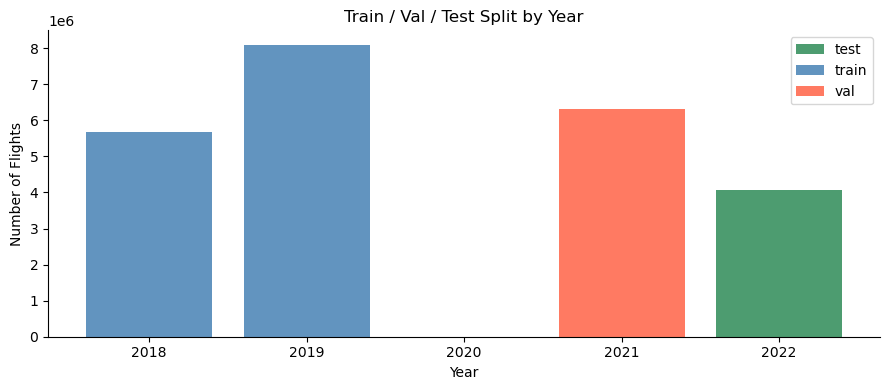

In [4]:
yearly = df.groupby(['Year', 'split']).size().reset_index(name='count')

colors = {'train': 'steelblue', 'val': 'tomato', 'test': 'seagreen'}
fig, ax = plt.subplots(figsize=(9, 4))

for split, grp in yearly.groupby('split'):
    ax.bar(grp['Year'], grp['count'], label=split,
           color=colors[split], alpha=0.85)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Flights')
ax.set_title('Train / Val / Test Split by Year')
ax.legend()
plt.tight_layout()
plt.show()

## Step 2: Cyclical Time Encoding

Month and day of week are cyclical (December is close to January, Sunday is close to Monday). In order for the model to treat them as close together,we fix it with sin/cos encoding.

Capturing seasonal patterns for cancellation rate

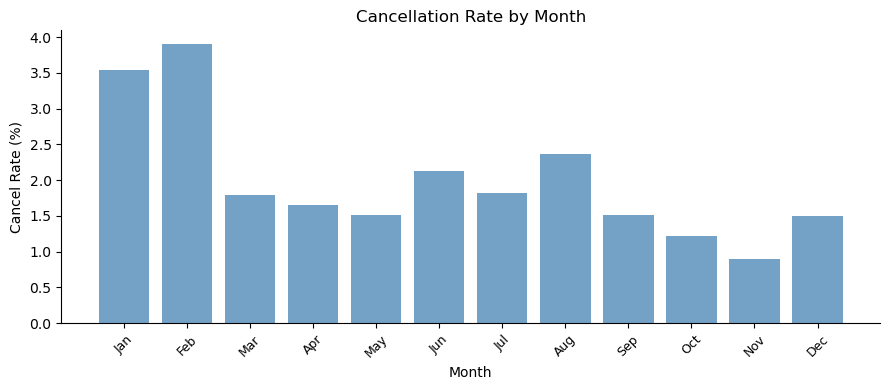

In [5]:
# cancellation rate by month -- this is what we want the model to learn
cancel_by_month = df.groupby('Month')['is_cancelled'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cancel_by_month.index, cancel_by_month.values, color='steelblue', alpha=0.75)
ax.set_title('Cancellation Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Cancel Rate (%)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# sin/cos encoding for month, day of week, and hour
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['dow_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

df['hour_sin'] = np.sin(2 * np.pi * df['dep_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['dep_hour'] / 24)

print('cyclical features added')

cyclical features added


## Step 3: Seasonal and Time-of-Day Flags

Looking at delay and cancellation rates by time of day and season to decide which binary flags to add.

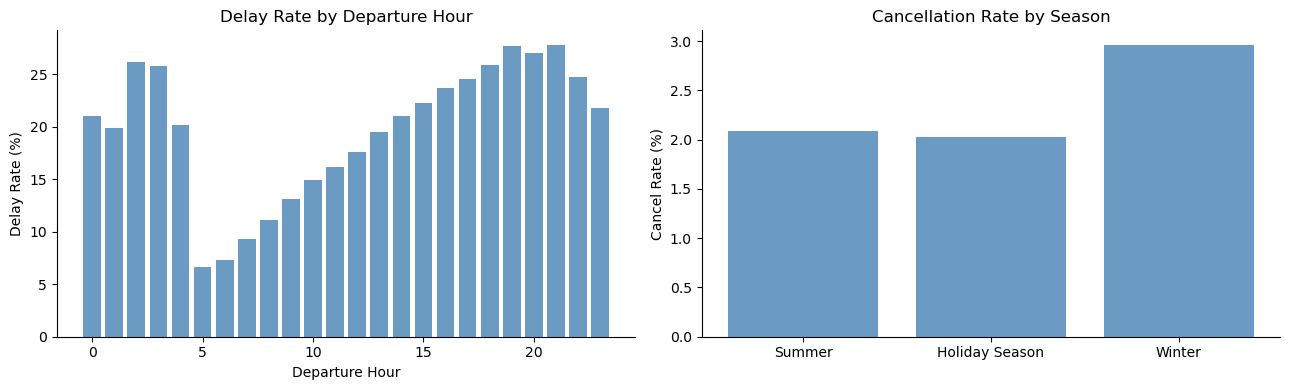

In [7]:
# delay rate by hour -- evening flights have the highest delay rates
# because delays cascade throughout the day
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

delay_by_hour = df.groupby('dep_hour')['is_delayed'].mean() * 100
axes[0].bar(delay_by_hour.index, delay_by_hour.values, color='steelblue', alpha=0.8)
axes[0].set_title('Delay Rate by Departure Hour')
axes[0].set_xlabel('Departure Hour')
axes[0].set_ylabel('Delay Rate (%)')

# cancel rate by season -- just the three seasons we're actually flagging
season_labels = ['Summer', 'Holiday Season', 'Winter']
cancel_rates = [
    df[df['Month'].isin([6,7,8])]['is_cancelled'].mean() * 100,
    df[df['Month'].isin([11,12,1])]['is_cancelled'].mean() * 100,
    df[df['Month'].isin([12,1,2])]['is_cancelled'].mean() * 100,
]
axes[1].bar(season_labels, cancel_rates, color='steelblue', alpha=0.8)
axes[1].set_title('Cancellation Rate by Season')
axes[1].set_ylabel('Cancel Rate (%)')

plt.tight_layout()
plt.show()

In [8]:
# seasonal flags
df['is_summer']         = df['Month'].isin([6, 7, 8]).astype(int)
df['is_holiday_season'] = df['Month'].isin([11, 12, 1]).astype(int)
df['is_winter']         = df['Month'].isin([12, 1, 2]).astype(int)

# time of day
df['is_early_morning'] = df['dep_hour'].isin([5, 6, 7]).astype(int)
df['is_morning_peak']  = df['dep_hour'].between(8, 11).astype(int)
df['is_evening_peak']  = df['dep_hour'].between(17, 20).astype(int)
df['is_red_eye']       = df['dep_hour'].isin([0, 1, 2, 3, 4]).astype(int)

print('seasonal flag counts:')
print(df[['is_summer','is_holiday_season','is_winter']].sum())

seasonal flag counts:
is_summer            6338834
is_holiday_season    5818385
is_winter            5668562
dtype: int64


Evening flights have noticeably higher delay rates, makes sense since delays cascade throughout the day. Winter and holiday season both have elevated cancellation rates.

## Step 4: Weather Threshold Features

Raw weather values are continuous but there are meaningful thresholds (visibility below 3 miles triggers instrument approaches, wind gusts above 35 knots can ground flights). 

Let's see if these thresholds actually show up in the cancellation rates.

In [9]:
# first let's look at the distribution of weather variables to decide on thresholds
weather_cols = ['tmpf', 'vsby', 'sknt', 'gust', 'p01i', 'relh']
print(df[weather_cols].describe().round(2))

              tmpf         vsby         sknt         gust         p01i  \
count  23377571.00  23377957.00  23377957.00  15891738.00  23377571.00   
mean         60.86         9.32         7.04        20.11         0.03   
std          18.20         1.56         3.95         4.26         0.26   
min         -27.90         0.02         0.00         8.00         0.00   
25%          48.50         9.46         4.33        17.00         0.00   
50%          62.60        10.00         6.45        19.00         0.00   
75%          74.94        10.00         9.21        22.00         0.00   
max         117.00        12.00        97.00        73.00        33.98   

              relh  
count  23355207.00  
mean         64.49  
std          19.67  
min           1.74  
25%          51.73  
50%          66.62  
75%          80.09  
max         100.00  


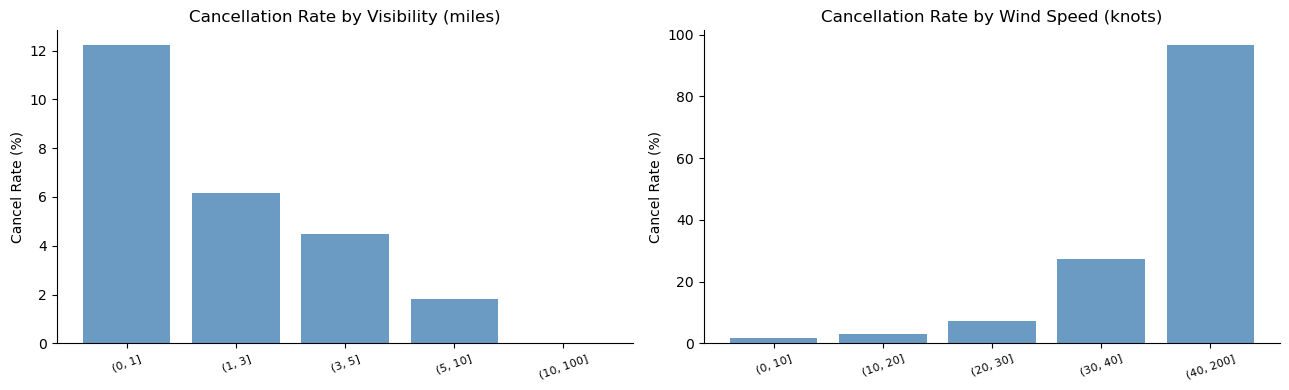

In [10]:
# visibility and wind speed both show a clear jump at certain thresholds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vis_bins = pd.cut(df['vsby'], bins=[0, 1, 3, 5, 10, 100])
cancel_by_vis = df.groupby(vis_bins, observed=True)['is_cancelled'].mean() * 100
axes[0].bar(range(len(cancel_by_vis)), cancel_by_vis.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(cancel_by_vis)))
axes[0].set_xticklabels([str(b) for b in cancel_by_vis.index], rotation=20, fontsize=8)
axes[0].set_title('Cancellation Rate by Visibility (miles)')
axes[0].set_ylabel('Cancel Rate (%)')

wind_bins = pd.cut(df['sknt'], bins=[0, 10, 20, 30, 40, 200])
cancel_by_wind = df.groupby(wind_bins, observed=True)['is_cancelled'].mean() * 100
axes[1].bar(range(len(cancel_by_wind)), cancel_by_wind.values, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(cancel_by_wind)))
axes[1].set_xticklabels([str(b) for b in cancel_by_wind.index], rotation=20, fontsize=8)
axes[1].set_title('Cancellation Rate by Wind Speed (knots)')
axes[1].set_ylabel('Cancel Rate (%)')

plt.tight_layout()
plt.show()

Based on the describe() and plots, here are the thresholds I decided on:
- `vsby < 3` miles is where cancellation rate jumps sharply (instrument conditions kick in)
- `sknt > 20` knots is the inflection point for wind speed
- `gust > 35` knots is above the 75th percentile and the cancellation rate spikes
- `tmpf < 32` F = below freezing
- `p01i > 0` = any precipitation at all

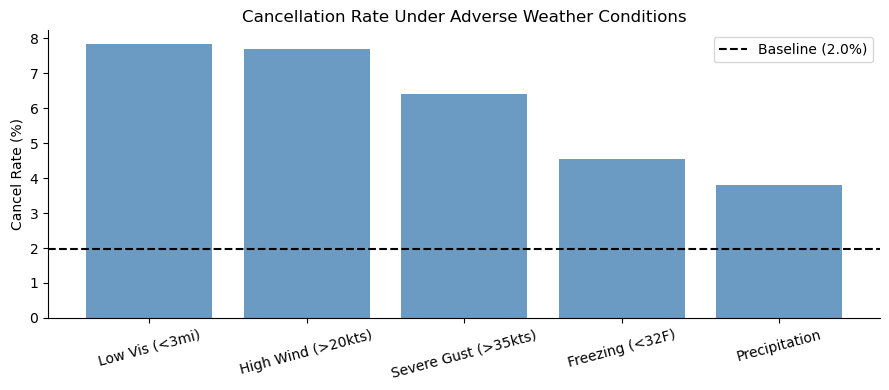

In [11]:
df['low_visibility']   = (df['vsby'] < 3).astype(int)
df['high_wind']        = (df['sknt'] > 20).astype(int)
df['wind_gust_severe'] = (df['gust'] > 35).astype(int)
df['freezing']         = (df['tmpf'] < 32).astype(int)
df['has_precip']       = (df['p01i'] > 0).astype(int)

baseline = df['is_cancelled'].mean() * 100
flags  = ['low_visibility', 'high_wind', 'wind_gust_severe', 'freezing', 'has_precip']
labels = ['Low Vis (<3mi)', 'High Wind (>20kts)', 'Severe Gust (>35kts)', 'Freezing (<32F)', 'Precipitation']
rates  = [df[df[f] == 1]['is_cancelled'].mean() * 100 for f in flags]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, rates, color='steelblue', alpha=0.8)
ax.axhline(baseline, color='black', linestyle='--', lw=1.5,
           label=f'Baseline ({baseline:.1f}%)')
ax.set_title('Cancellation Rate Under Adverse Weather Conditions')
ax.set_ylabel('Cancel Rate (%)')
ax.tick_params(axis='x', rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

Low visibility and severe gusts have cancellation rates well above baseline. Adding these as binary flags gives the model a clearer signal than the raw continuous values.

## Step 5: Label Encoding Categoricals

XGBoost needs numeric inputs. Using label encoding for airline, origin, destination since they have high cardinality  (one-hot encoding would create thousands of columns).

In [12]:
from sklearn.preprocessing import LabelEncoder


In [13]:
# save original string values before label encoding so we can use them in plots
airline_names = df['Airline'].copy()
origin_names  = df['Origin'].copy()

In [14]:
# label encode categoricals
cat_cols = ['Airline', 'Origin', 'region']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'{col}: {len(le.classes_)} unique values')

Airline: 27 unique values
Origin: 384 unique values
region: 4 unique values


## Step 6: Target Encoding

For airline, origin, and route we want to encode the historical delay/cancel rate. 

Important: we compute this from the training set only and merge onto val/test to prevent leakage.

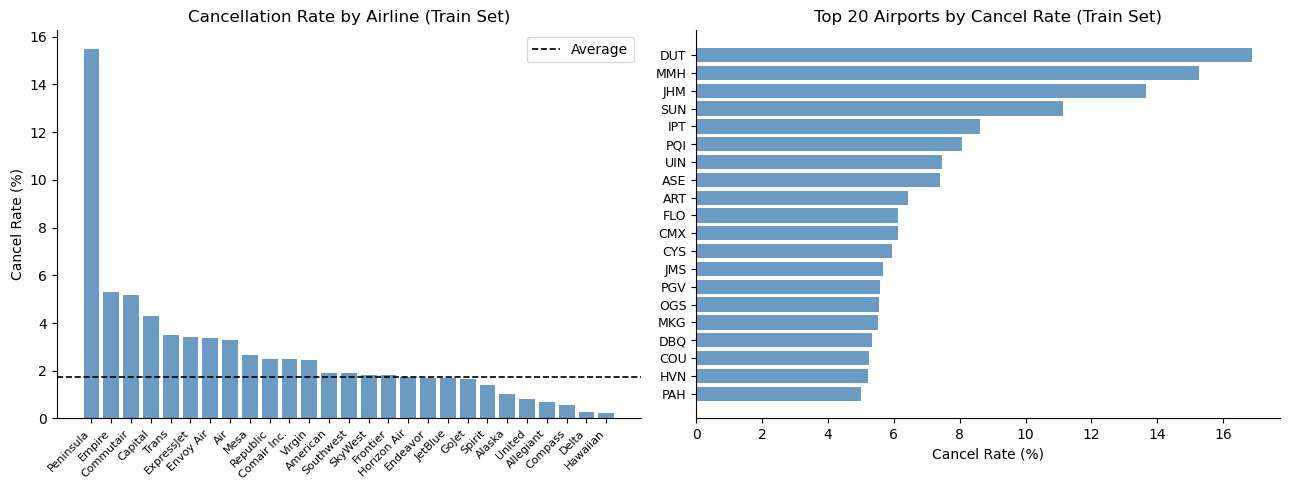

In [15]:
train_mask = df['split'] == 'train'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tmp = df[train_mask].copy()
tmp['Airline_name'] = airline_names[train_mask]
tmp['Origin_name']  = origin_names[train_mask]

# shorten airline names to first word so they fit on the axis
airline_cancel = tmp.groupby('Airline_name')['is_cancelled'].mean().sort_values(ascending=False) * 100
short_names = [name.split()[0] if len(name) > 12 else name for name in airline_cancel.index]

axes[0].bar(range(len(airline_cancel)), airline_cancel.values, color='steelblue', alpha=0.8)
axes[0].axhline(tmp['is_cancelled'].mean()*100,
                color='black', linestyle='--', lw=1.2, label='Average')
axes[0].set_xticks(range(len(airline_cancel)))
axes[0].set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Cancellation Rate by Airline (Train Set)')
axes[0].set_ylabel('Cancel Rate (%)')
axes[0].legend()

origin_cancel = (tmp.groupby('Origin_name')['is_cancelled']
                 .mean()
                 .sort_values(ascending=False)
                 .head(20) * 100)
axes[1].barh(range(20), origin_cancel.values, color='steelblue', alpha=0.8)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(origin_cancel.index.tolist(), fontsize=9)
axes[1].set_title('Top 20 Airports by Cancel Rate (Train Set)')
axes[1].set_xlabel('Cancel Rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

There's real variation across airlines and airports.

Some airlines cancel 3x more than others. Target encoding captures this signal.

In [16]:
def smooth_target_encode(df, col, target_col, train_mask, M=5000):
    global_mean = df.loc[train_mask, target_col].mean()
    stats = (df[train_mask]
             .groupby(col)[target_col]
             .agg(['sum', 'count'])
             .rename(columns={'sum': 'n_pos', 'count': 'n'}))
    stats['encoded'] = (stats['n_pos'] + M * global_mean) / (stats['n'] + M)
    return df[col].map(stats['encoded']).fillna(global_mean)

df['airline_cancel_rate'] = smooth_target_encode(df, 'Airline', 'is_cancelled', train_mask, M=10000)
df['airline_delay_rate']  = smooth_target_encode(df, 'Airline', 'is_delayed',   train_mask, M=10000)
df['origin_cancel_rate']  = smooth_target_encode(df, 'Origin',  'is_cancelled', train_mask, M=5000)
df['origin_delay_rate']   = smooth_target_encode(df, 'Origin',  'is_delayed',   train_mask, M=5000)


## Step 7: Lag Features

Past performance at an airport is a strong signal for future disruptions. If ORD airprot had a bad day yesterday, there's a higher chance of issues today due to cascading effects.

Let's verify that relationship actually exists before adding the features.

* does yesterday's cancel rate predict today's?

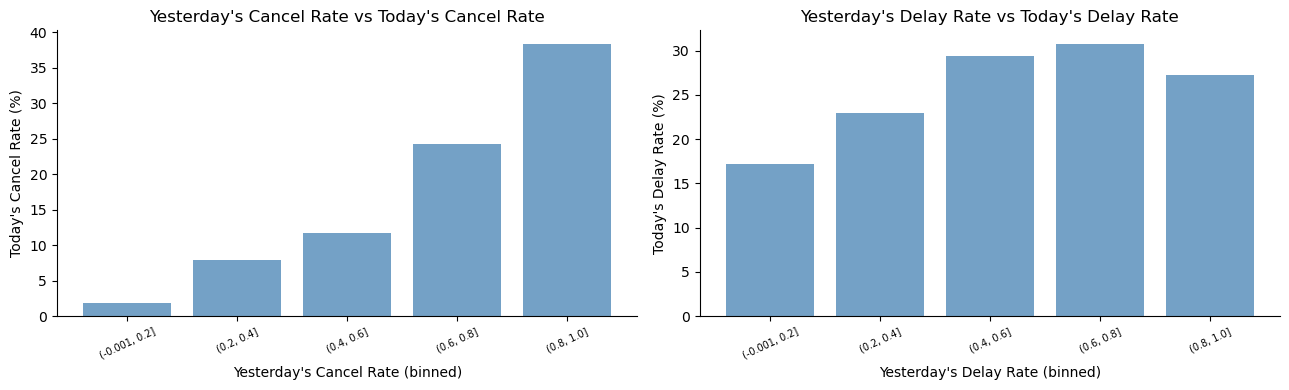

In [17]:
# compute daily airport stats (train only)
daily = (df[train_mask]
         .groupby(['Origin', 'FlightDate'])
         .agg(
             lag1_cancel_rate=('is_cancelled', 'mean'),
             lag1_delay_rate=('is_delayed', 'mean'),
             lag1_volume=('is_cancelled', 'count'),
         )
         .reset_index())

# shift by 1 day
daily['FlightDate'] = daily['FlightDate'] + pd.Timedelta(days=1)

# merge onto full dataset
df = df.merge(daily, on=['Origin', 'FlightDate'], how='left')
df['lag1_cancel_rate'] = df['lag1_cancel_rate'].fillna(df.loc[train_mask, 'is_cancelled'].mean())
df['lag1_delay_rate']  = df['lag1_delay_rate'].fillna(df.loc[train_mask, 'is_delayed'].mean())
df['lag1_volume']      = df['lag1_volume'].fillna(df.loc[train_mask, 'lag1_volume'].mean())


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = pd.cut(df['lag1_cancel_rate'], bins=5)
today_cancel = df.groupby(bins, observed=True)['is_cancelled'].mean() * 100
axes[0].bar(range(len(today_cancel)), today_cancel.values, color='steelblue', alpha=0.75)
axes[0].set_xticks(range(len(today_cancel)))
axes[0].set_xticklabels([str(b) for b in today_cancel.index], rotation=25, fontsize=7)
axes[0].set_title("Yesterday's Cancel Rate vs Today's Cancel Rate")
axes[0].set_ylabel("Today's Cancel Rate (%)")
axes[0].set_xlabel("Yesterday's Cancel Rate (binned)")

bins2 = pd.cut(df['lag1_delay_rate'], bins=5)
today_delay = df.groupby(bins2, observed=True)['is_delayed'].mean() * 100
axes[1].bar(range(len(today_delay)), today_delay.values, color='steelblue', alpha=0.75)
axes[1].set_xticks(range(len(today_delay)))
axes[1].set_xticklabels([str(b) for b in today_delay.index], rotation=25, fontsize=7)
axes[1].set_title("Yesterday's Delay Rate vs Today's Delay Rate")
axes[1].set_ylabel("Today's Delay Rate (%)")
axes[1].set_xlabel("Yesterday's Delay Rate (binned)")

plt.tight_layout()
plt.show()

Strong relationship of airports that had high cancellation/delay rates yesterday are more likely to have them today. Bad weather systems last multiple days and operational disruptions take time to recover from.

## Step 8: Model B Interaction Features

For Model B (delay prediction) we add interaction features that combine weather and time-of-day signals. The idea is that bad weather during peak hours is worse than bad weather at off-peak hours.

* does precipitation during peak hours have a higher delay rate than either alone?

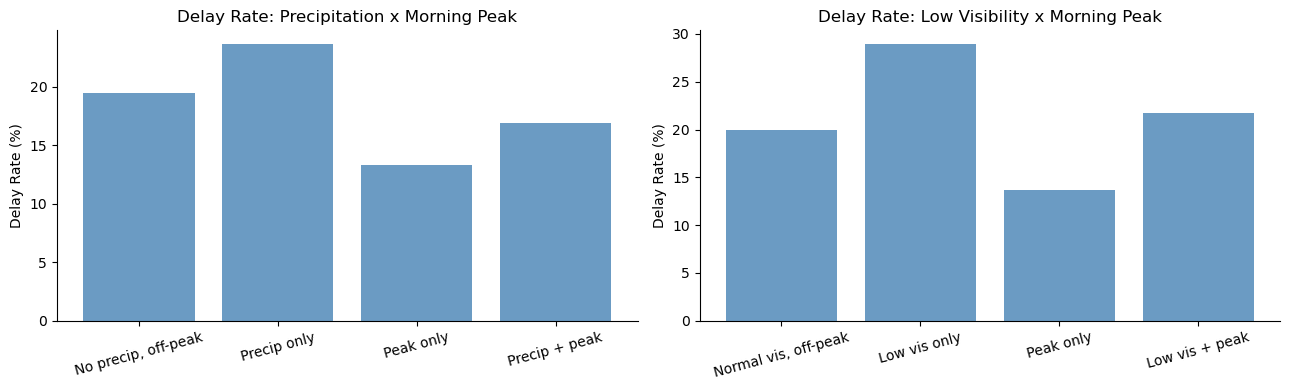

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

groups = {
    'No precip, off-peak': df[(df['has_precip']==0) & (df['is_morning_peak']==0)]['is_delayed'].mean()*100,
    'Precip only':         df[(df['has_precip']==1) & (df['is_morning_peak']==0)]['is_delayed'].mean()*100,
    'Peak only':           df[(df['has_precip']==0) & (df['is_morning_peak']==1)]['is_delayed'].mean()*100,
    'Precip + peak':       df[(df['has_precip']==1) & (df['is_morning_peak']==1)]['is_delayed'].mean()*100,
}
axes[0].bar(groups.keys(), groups.values(), color='steelblue', alpha=0.8)
axes[0].set_title('Delay Rate: Precipitation x Morning Peak')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

groups2 = {
    'Normal vis, off-peak': df[(df['low_visibility']==0) & (df['is_morning_peak']==0)]['is_delayed'].mean()*100,
    'Low vis only':         df[(df['low_visibility']==1) & (df['is_morning_peak']==0)]['is_delayed'].mean()*100,
    'Peak only':            df[(df['low_visibility']==0) & (df['is_morning_peak']==1)]['is_delayed'].mean()*100,
    'Low vis + peak':       df[(df['low_visibility']==1) & (df['is_morning_peak']==1)]['is_delayed'].mean()*100,
}
axes[1].bar(groups2.keys(), groups2.values(), color='steelblue', alpha=0.8)
axes[1].set_title('Delay Rate: Low Visibility x Morning Peak')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

The interaction shows decent signal.

- precipitation during morning peak has a higher delay rate than either condition alone. This justifies 

In [19]:
# add interaction features for model B
df['precip_x_peak']       = df['has_precip']      * df['is_morning_peak']
df['wind_x_peak']         = df['high_wind']        * df['is_morning_peak']
df['lowvis_x_peak']       = df['low_visibility']   * df['is_morning_peak']
df['precip_x_evening']    = df['has_precip']       * df['is_evening_peak']
df['wind_x_evening']      = df['high_wind']        * df['is_evening_peak']
df['nas_x_peak']          = df['nas_delay']        * df['is_morning_peak']
df['lag_cancel_x_winter'] = df['lag1_cancel_rate'] * df['is_winter']
df['lag_delay_x_peak']    = df['lag1_delay_rate']  * df['is_morning_peak']


## Step 9: Final Feature Set

In [20]:
model_a_features = [
    # time
    'Month', 'DayOfWeek', 'dep_hour', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'hour_sin', 'hour_cos', 'is_summer', 'is_holiday_season', 'is_winter',
    'is_early_morning', 'is_morning_peak', 'is_evening_peak', 'is_red_eye',
    # flight
    'Airline', 'Origin', 'Distance', 'region',
    # weather
    'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'low_visibility', 'high_wind', 'wind_gust_severe', 'freezing', 'has_precip',
    # airport operations
    'nas_delay', 'weather_delay', 'late_aircraft_delay',
    # airport metadata
    'airport_elevation', 'num_runways', 'max_runway_length_ft',
    # target encoding
    'airline_cancel_rate', 'airline_delay_rate', 'origin_cancel_rate', 'origin_delay_rate',
    # lag features
    'lag1_cancel_rate', 'lag1_delay_rate', 'lag1_volume',
]

interaction_features = [
    'precip_x_peak', 'wind_x_peak', 'lowvis_x_peak',
    'precip_x_evening', 'wind_x_evening', 'nas_x_peak',
    'lag_cancel_x_winter', 'lag_delay_x_peak',
]

model_b_features = model_a_features + interaction_features

print(f'Model A features: {len(model_a_features)}')
print(f'Model B features: {len(model_b_features)}')

Model A features: 44
Model B features: 52


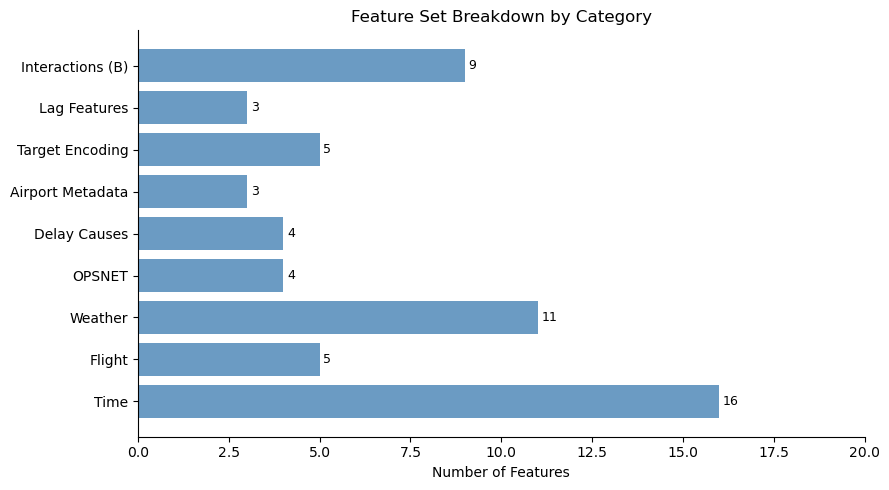

In [21]:
# feature category breakdown
categories = {
    'Time':               16,
    'Flight':              5,
    'Weather':            11,
    'OPSNET':              4,
    'Delay Causes':        4,
    'Airport Metadata':    3,
    'Target Encoding':     5,
    'Lag Features':        3,
    'Interactions (B)':    9,
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue'] * 9

bars = ax.barh(list(categories.keys()), list(categories.values()),
               color=colors, alpha=0.8)
for bar, count in zip(bars, categories.values()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)

ax.set_xlabel('Number of Features')
ax.set_title('Feature Set Breakdown by Category')
ax.set_xlim(0, 20)
plt.tight_layout()
plt.show()